In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

In [40]:
import joblib
import json
import os

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.model_selection import train_test_split, cross_val_score

In [3]:
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

D:\Installed_Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
warnings.filterwarnings("ignore")
 
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor"   : "#1a1a2e",
    "axes.labelcolor"  : "#e0e0e0",
    "xtick.color"      : "#e0e0e0",
    "ytick.color"      : "#e0e0e0",
    "text.color"       : "#e0e0e0",
    "grid.color"       : "#2a2a4a",
    "grid.linewidth"   : 0.5,
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
 
TESLA_RED = "#E31937"
GOLD      = "#FFD700"
CYAN      = "#00D4FF"
GREEN     = "#00FF88"
PURPLE    = "#BF5FFF"
ORANGE    = "#FF8C00"

COL_PALETTE = [CYAN, GOLD, GREEN, TESLA_RED, PURPLE, ORANGE, "#FF69B4", "#00CED1"]

In [5]:
def plot_distributions(df, columns, plot_type="both", bins=40, ncols=3):
    """
    Plot distribution of selected numeric columns in a grid layout.
 
    Parameters
    ----------
    df        : DataFrame  — your Tesla dataframe
    columns   : list       — column names to plot
                             e.g. ["Open", "High", "Low", "Close", "Volume"]
    plot_type : str        — what to draw inside each subplot
                             "hist"  → histogram only
                             "kde"   → KDE curve only
                             "both"  → histogram + KDE overlaid  (default)
    bins      : int        — number of histogram bins (default 40)
    ncols     : int        — number of columns in grid (default 3)
 
    Returns
    -------
    None — displays the plot inline (notebook ready)
 
    Example usage
    -------------
    # all numeric columns
    plot_distributions(df, ["Open", "High", "Low", "Close", "Adj Close", "Volume"])
 
    # only price columns, KDE only
    plot_distributions(df, ["Open", "Close", "Adj Close"], plot_type="kde")
 
    # histogram only, 2-column grid
    plot_distributions(df, ["Close", "Volume"], plot_type="hist", ncols=2)
    """
 
    # ── Validation ────────────────────────────────────────────────────────────
    valid_types = ("hist", "kde", "both")
    if plot_type not in valid_types:
        print(f"⚠️  Invalid plot_type='{plot_type}'. Choose from: {valid_types}")
        return
 
    # keep only columns that exist in df
    missing = [c for c in columns if c not in df.columns]
    if missing:
        print(f"⚠️  Columns not found in dataframe: {missing}")
        columns = [c for c in columns if c in df.columns]
    if not columns:
        print("⚠️  No valid columns to plot.")
        return
 
    # keep only numeric columns
    non_numeric = [c for c in columns if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        print(f"⚠️  Skipping non-numeric columns: {non_numeric}")
        columns = [c for c in columns if pd.api.types.is_numeric_dtype(df[c])]
    if not columns:
        print("⚠️  No numeric columns left to plot.")
        return
 
    # ── Grid dimensions ───────────────────────────────────────────────────────
    n     = len(columns)
    ncols = min(ncols, n)                    # don't make more cols than plots
    nrows = int(np.ceil(n / ncols))
 
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False)
 
    type_label = {"hist": "Histogram", "kde": "KDE", "both": "Histogram + KDE"}
 
    for idx, col in enumerate(columns):
        row = idx // ncols
        col_pos = idx % ncols
        ax  = axes[row][col_pos]
        color = COL_PALETTE[idx % len(COL_PALETTE)]
        data  = df[col].dropna()
 
        # ── Draw selected plot type ───────────────────────────────────────────
        if plot_type == "hist":
            sns.histplot(data, bins=bins, ax=ax,
                         color=color, alpha=0.75,
                         edgecolor="#0f0f0f", linewidth=0.4)
 
        elif plot_type == "kde":
            sns.kdeplot(data, ax=ax,
                        color=color, linewidth=2.5, fill=True, alpha=0.35)
 
        elif plot_type == "both":
            sns.histplot(data, bins=bins, ax=ax,
                         color=color, alpha=0.55,
                         edgecolor="#0f0f0f", linewidth=0.3,
                         stat="density")                     # density so KDE scale matches
            sns.kdeplot(data, ax=ax,
                        color="white", linewidth=2,
                        linestyle="--", alpha=0.85)
 
        # ── Stats lines ───────────────────────────────────────────────────────
        mean_val   = data.mean()
        median_val = data.median()
 
        ax.axvline(mean_val,   color=GOLD,  linewidth=1.5,
                   linestyle="--", label=f"Mean   {mean_val:.2f}")
        ax.axvline(median_val, color=GREEN, linewidth=1.5,
                   linestyle=":",  label=f"Median {median_val:.2f}")
 
        # ── Skewness annotation ───────────────────────────────────────────────
        skew = data.skew()
        skew_dir = "Right skewed ▶" if skew > 0.5 else ("Left skewed ◀" if skew < -0.5 else "Normal ≈")
        ax.text(0.97, 0.95, f"Skew: {skew:.2f}  {skew_dir}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=7.5, color="#cccccc",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="#0f0f0f", alpha=0.6, edgecolor="none"))
 
        ax.set_title(f"{col}", fontsize=11, color=color, pad=8)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel("Density" if plot_type in ("kde", "both") else "Count", fontsize=9)
        ax.legend(fontsize=7.5, loc="upper left")
 
    # ── Hide unused subplots ──────────────────────────────────────────────────
    for empty in range(n, nrows * ncols):
        fig.delaxes(axes[empty // ncols][empty % ncols])
 
    # ── Master title ──────────────────────────────────────────────────────────
    fig.suptitle(
        f"Car Price — Distribution Analysis  |  {type_label[plot_type]}\n"
        f"Gold dashed = Mean   |   Green dotted = Median",
        fontsize=13, color=GOLD, y=1.01
    )
 
    plt.tight_layout()
    plt.show()
 
    # ── Summary table printed below graph ────────────────────────────────────
    print(f"\n📊 Distribution Summary  ({type_label[plot_type]})")
    print("-" * 115)
    print(f"{'Column':<25} {'Mean':>17} {'Median':>17} {'Std':>17} {'Skew':>17}  Status")
    print("-" * 115)

    # Build list of stats, sort by skewness ascending
    stats = []
    for col in columns:
        d = df[col].dropna()
        stats.append({
            'col': col,
            'mean': d.mean(),
            'median': d.median(),
            'std': d.std(),
            'skew': d.skew()
        })

    stats_sorted = sorted(stats, key=lambda x: x['skew'])  # ascending skew

    for s in stats_sorted:
        if abs(s['skew']) > 1:     flag = "⚠️  High"
        elif abs(s['skew']) > 0.5: flag = "〰️  Moderate"
        else:                      flag = "✓  Normal"

        print(f"{s['col']:<25} {s['mean']:>17.2f} {s['median']:>17.2f} "
              f"{s['std']:>17.2f} {s['skew']:>17.3f}  {flag}")
    print("-" * 115)

In [6]:
def auto_transform_features(df, columns, skew_threshold=0.5):
    """
    Auto-detects skewed columns and finds best transformation.

    Parameters
    ----------
    df              : DataFrame
    columns         : list of column names to check
    skew_threshold  : abs skew above this = needs transform (default 0.5)

    Returns
    -------
    df_out          : DataFrame with transformed columns added
    transform_map   : dict  {col: best_transform_name}
    report          : list of dicts for printing
    """

    df_out = df.copy()
    transform_map = {}
    report = []

    for col in columns:
        data       = df[col].dropna()
        data_np    = data.to_numpy().astype(float)   # ← clean numpy array, no pandas index
        data_idx   = data.index
        original_skew = pd.Series(data_np).skew()

        # ── STEP 1: Check if transformation needed ────────────────
        if abs(original_skew) <= skew_threshold:
            report.append({
                'column'     : col,
                'orig_skew'  : original_skew,
                'status'     : 'SKIP',
                'best_method': 'None',
                'final_skew' : original_skew,
                'improvement': 0.0
            })
            continue

        # ── STEP 2: Define candidate transformations ───────────────
        candidates = {}

        # 1. Log1p — requires all values >= 0
        if data_np.min() >= 0:
            candidates['log1p'] = np.log1p(data_np)

        # 2. Square Root — requires all values >= 0
        if data_np.min() >= 0:
            candidates['sqrt'] = np.sqrt(data_np)

        # 3. Cube Root — works on any values
        candidates['cbrt'] = np.cbrt(data_np)

        # 4. Box-Cox — requires all values > 0 strictly
        if data_np.min() > 0:
            try:
                transformed, _ = stats.boxcox(data_np)
                candidates['boxcox'] = transformed
            except Exception:
                pass

        # 5. Yeo-Johnson — works on any values
        try:
            transformed, _ = stats.yeojohnson(data_np)
            candidates['yeo-johnson'] = transformed
        except Exception:
            pass

        # 6. Reciprocal — requires no zeros
        if not np.any(data_np == 0):
            candidates['reciprocal'] = 1 / data_np

        # 7. Square — only useful if left skewed
        if original_skew < -0.5:
            candidates['square'] = data_np ** 2

        # ── STEP 3: Find best (minimum abs skew) ──────────────────
        best_method = None
        best_skew   = original_skew
        best_array  = None

        for method, arr in candidates.items():
            s = pd.Series(arr).skew()
            if abs(s) < abs(best_skew):
                best_skew   = s
                best_method = method
                best_array  = arr

        # ── STEP 4: Apply best transformation ─────────────────────
        if best_method and abs(best_skew) < abs(original_skew):
            df_out[col] = pd.Series(best_array, index=data_idx).reindex(df_out.index)  # replace original
            transform_map[col] = best_method
            status = 'TRANSFORMED'
        else:
            best_method = 'None (no improvement)'
            best_skew   = original_skew
            status      = 'NO IMPROVEMENT'

        report.append({
            'column'     : col,
            'orig_skew'  : original_skew,
            'status'     : status,
            'best_method': best_method,
            'final_skew' : best_skew,
            'improvement': abs(original_skew) - abs(best_skew)
        })

    # ── STEP 5: Print structured report ───────────────────────────
    _print_report(report, skew_threshold)

    return df_out, transform_map, report

def _print_report(report, skew_threshold):

    report_sorted = sorted(report, key=lambda x: x['improvement'], reverse=True)

    W = 90
    print(f"\n{'═' * W}")
    print(f"  AUTO TRANSFORMATION REPORT   |   skew threshold: ±{skew_threshold}")
    print(f"{'═' * W}")
    print(f"  {'Column':<20} {'Orig Skew':>10} {'Final Skew':>11} "
          f"{'Improvement':>12} {'Method':<18} {'Status'}")
    print(f"{'─' * W}")

    skip_count        = 0
    transformed_count = 0
    no_improve_count  = 0

    for r in report_sorted:
        if r['status'] == 'SKIP':
            icon = '✓ '
            skip_count += 1
        elif r['status'] == 'TRANSFORMED':
            icon = '⚡'
            transformed_count += 1
        else:
            icon = '〰️'
            no_improve_count += 1

        if abs(r['final_skew']) > 1:       skew_flag = '⚠️  High'
        elif abs(r['final_skew']) > 0.5:   skew_flag = '〰️  Mod'
        else:                              skew_flag = '✓  Normal'

        print(f"  {r['column']:<20} {r['orig_skew']:>10.3f} {r['final_skew']:>11.3f} "
              f"{r['improvement']:>12.3f} {r['best_method']:<18} {icon} {skew_flag}")

    print(f"{'─' * W}")

    total = len(report)
    print(f"\n  Total columns checked : {total}")
    print(f"  ✓  Skipped (normal)   : {skip_count}  ({skip_count/total*100:.0f}%)")
    print(f"  ⚡ Transformed         : {transformed_count}  ({transformed_count/total*100:.0f}%)")
    print(f"  〰️  No improvement     : {no_improve_count}  ({no_improve_count/total*100:.0f}%)")
    print(f"\n  New columns replaced with orignal columns ✅")
    print(f"{'═' * W}\n")

In [7]:
def plot_category_vs_target(df, col, target, top_n=20):
    """
    Plots relationship between a categorical column and target column.
    Uses boxplot for low-cardinality columns, and bar chart of mean target
    (sorted, top_n only) for high-cardinality columns like brand/model.
    """
    n_unique = df[col].nunique()

    plt.figure(figsize=(10, 5))

    if n_unique <= 10:
        # Low cardinality -> boxplot shows full distribution per category
        order = df.groupby(col)[target].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=col, y=target, order=order)
        plt.title(f"{target} distribution across '{col}' (n_unique={n_unique})")
        plt.xticks(rotation=45, ha='right')

    else:
        # High cardinality -> show mean target per category, top_n only, as bar chart
        mean_price = (
            df.groupby(col)[target]
            .mean()
            .sort_values(ascending=False)
            .head(top_n)
        )
        sns.barplot(x=mean_price.values, y=mean_price.index, orient='h')
        plt.title(f"Average {target} by '{col}' (top {top_n} of {n_unique} categories)")
        plt.xlabel(f"Mean {target}")
        plt.ylabel(col)

    plt.tight_layout()
    plt.show()


def plot_all_categoricals(df, cols, target):
    for col in cols:
        if col not in df.columns:
            print(f"Skipping '{col}' - not found in dataframe")
            continue
        plot_category_vs_target(df, col, target)

In [8]:
def _iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper, q1, q3, iqr


def _zscore_outlier_count(series, threshold=3.0):
    mean = series.mean()
    std = series.std()
    if std == 0 or pd.isna(std):
        return 0, mean, std
    z = (series - mean) / std
    count = (z.abs() > threshold).sum()
    return count, mean, std


def outlier_report(df, cols, z_threshold=3.0):
    """
    Returns a DataFrame report: one row per numerical column, showing
    outlier counts/percentages from both IQR and Z-score methods side by side.
    """
    rows = []

    for col in cols:
        if col not in df.columns:
            print(f"Skipping '{col}' - not found in dataframe")
            continue

        series = df[col].dropna()
        n = len(series)

        # IQR method
        lower, upper, q1, q3, iqr = _iqr_bounds(series)
        iqr_outliers = series[(series < lower) | (series > upper)]
        iqr_count = len(iqr_outliers)
        iqr_pct = round((iqr_count / n) * 100, 2) if n else 0

        # Z-score method
        z_count, mean, std = _zscore_outlier_count(series, threshold=z_threshold)
        z_pct = round((z_count / n) * 100, 2) if n else 0

        rows.append({
            'column': col,
            'n_values': n,
            'iqr_lower_bound': round(lower, 2),
            'iqr_upper_bound': round(upper, 2),
            'iqr_outlier_count': iqr_count,
            'iqr_outlier_pct': iqr_pct,
            'zscore_threshold': z_threshold,
            'zscore_outlier_count': z_count,
            'zscore_outlier_pct': z_pct,
            'min': round(series.min(), 2),
            'max': round(series.max(), 2),
        })

    report_df = pd.DataFrame(rows)
    return report_df


def outlier_rows(df, col, method='iqr', z_threshold=3.0):
    """
    Returns the actual outlier ROWS (full original rows, not just the column)
    for a single column, using either 'iqr' or 'zscore' method.
    Useful to inspect which specific cars are flagged.
    """
    series = df[col].dropna()

    if method == 'iqr':
        lower, upper, _, _, _ = _iqr_bounds(series)
        mask = (df[col] < lower) | (df[col] > upper)
    elif method == 'zscore':
        mean = series.mean()
        std = series.std()
        z = (df[col] - mean) / std
        mask = z.abs() > z_threshold
    else:
        raise ValueError("method must be 'iqr' or 'zscore'")

    return df[mask]

In [9]:
def analyzeDiscreteColumns(df : pd.DataFrame, cols : list):
    new_df = pd.DataFrame(index = cols, columns = ['total_values', 'n_unique', 'percentage_unique'])

    for col in cols:
        n_unique = df[col].nunique()
        new_df.loc[col, 'total_values'] = df.shape[0]
        new_df.loc[col, 'n_unique'] = n_unique
        new_df.loc[col, 'percentage_unique'] = f"{(n_unique / len(df)) * 100:.2f}%"

    return new_df

In [2]:
df = pd.read_csv("..\\data\\car.csv")

In [3]:
df.drop(['Unnamed: 0', 'car_name'], inplace=True, axis=1)

In [4]:
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
df.shape

(15411, 12)

In [6]:
df.isnull().sum()

brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [7]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15411 non-null  str    
 1   model              15411 non-null  str    
 2   vehicle_age        15411 non-null  int64  
 3   km_driven          15411 non-null  int64  
 4   seller_type        15411 non-null  str    
 5   fuel_type          15411 non-null  str    
 6   transmission_type  15411 non-null  str    
 7   mileage            15411 non-null  float64
 8   engine             15411 non-null  int64  
 9   max_power          15411 non-null  float64
 10  seats              15411 non-null  int64  
 11  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 1.9 MB


In [16]:
for col in df.select_dtypes(include=['str']).columns:
    print(f"-- {col} --\n\t{df[col].value_counts().index}")

-- brand --
	Index(['Maruti', 'Hyundai', 'Honda', 'Mahindra', 'Toyota', 'Ford',
       'Volkswagen', 'Renault', 'BMW', 'Tata', 'Mercedes-Benz', 'Skoda',
       'Audi', 'Datsun', 'Jaguar', 'Land Rover', 'Jeep', 'Kia', 'Porsche',
       'Volvo', 'MG', 'Mini', 'Nissan', 'Lexus', 'Isuzu', 'Bentley',
       'Maserati', 'ISUZU', 'Ferrari', 'Mercedes-AMG', 'Rolls-Royce', 'Force'],
      dtype='str', name='brand')
-- model --
	Index(['i20', 'Swift Dzire', 'Swift', 'Alto', 'City', 'Wagon R', 'Grand',
       'Innova', 'Verna', 'i10',
       ...
       'NX', 'RX', 'Aura', 'Ghibli', 'GTC4Lusso', 'Altroz', 'C', 'Ghost',
       'Quattroporte', 'Gurkha'],
      dtype='str', name='model', length=120)
-- seller_type --
	Index(['Dealer', 'Individual', 'Trustmark Dealer'], dtype='str', name='seller_type')
-- fuel_type --
	Index(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype='str', name='fuel_type')
-- transmission_type --
	Index(['Manual', 'Automatic'], dtype='str', name='transmission_type')


⚠️  Skipping non-numeric columns: ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


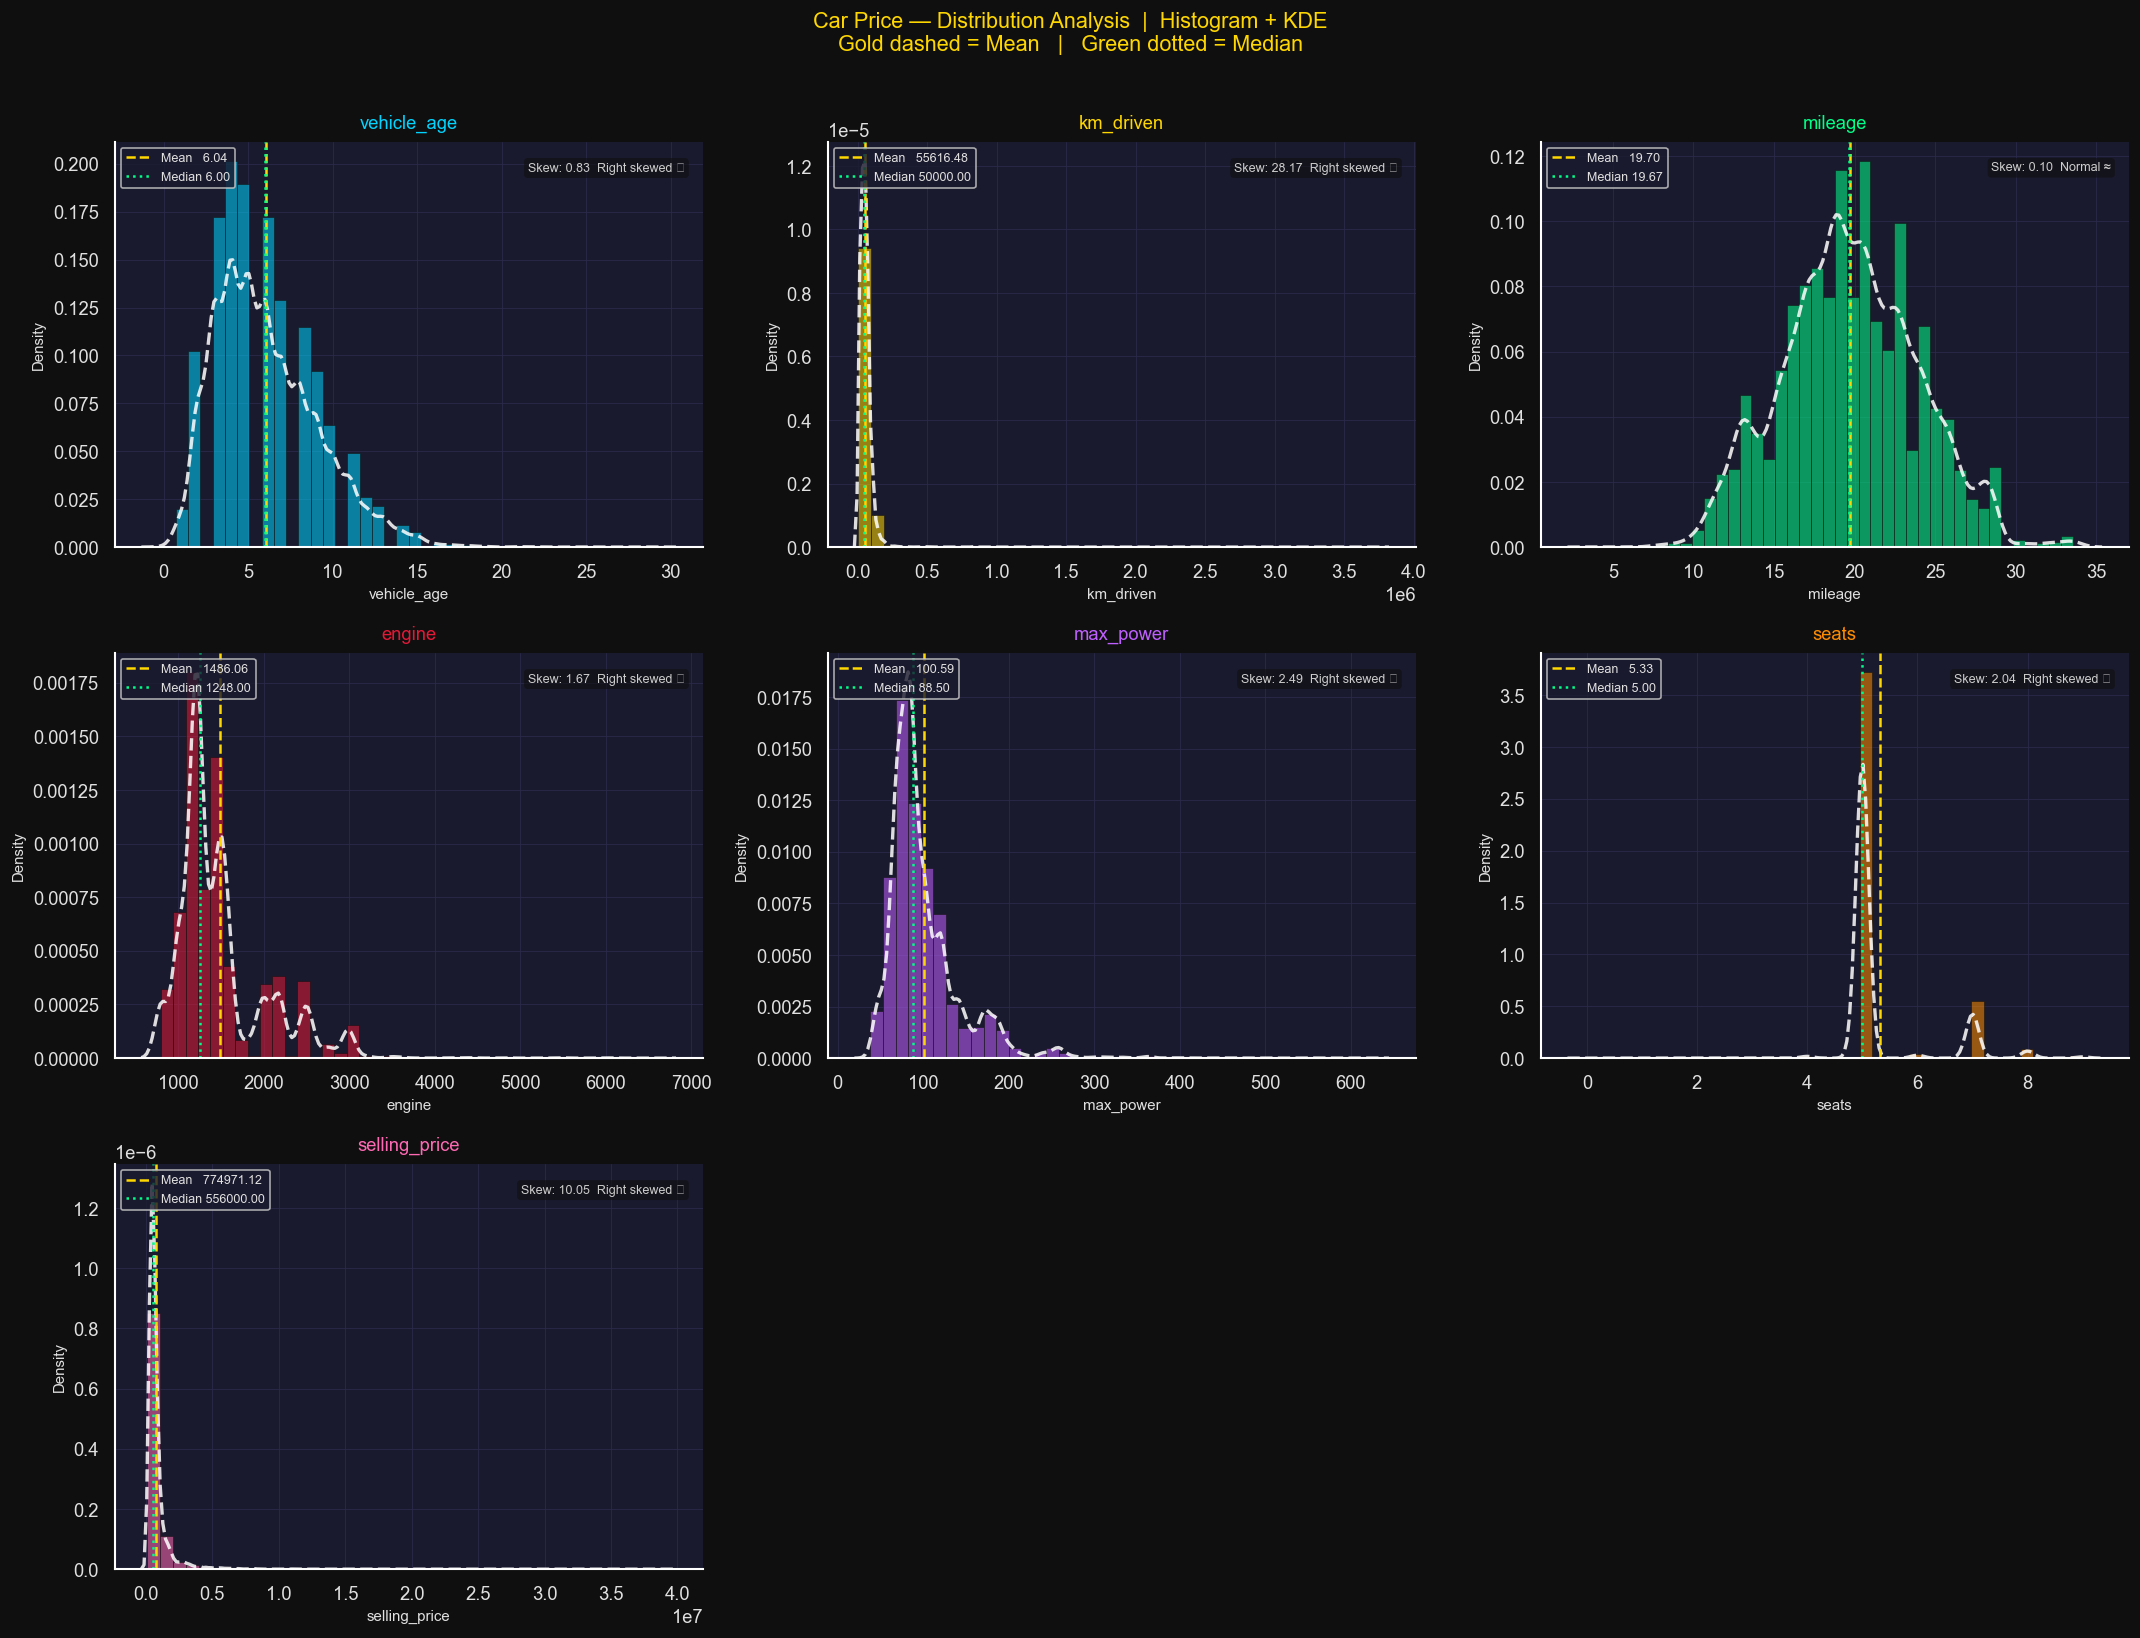


📊 Distribution Summary  (Histogram + KDE)
-------------------------------------------------------------------------------------------------------------------
Column                                 Mean            Median               Std              Skew  Status
-------------------------------------------------------------------------------------------------------------------
mileage                               19.70             19.67              4.17             0.105  ✓  Normal
vehicle_age                            6.04              6.00              3.01             0.834  〰️  Moderate
engine                              1486.06           1248.00            521.11             1.666  ⚠️  High
seats                                  5.33              5.00              0.81             2.040  ⚠️  High
max_power                            100.59             88.50             42.97             2.485  ⚠️  High
selling_price                     774971.12         556000.00         8941

In [17]:
plot_distributions(
    df,
    df.columns.tolist()
)

In [18]:
analyzeDiscreteColumns(df, ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type'])

,total_values,n_unique,percentage_unique
brand,15411,32,0.21%
model,15411,120,0.78%
seller_type,15411,3,0.02%
fuel_type,15411,5,0.03%
transmission_type,15411,2,0.01%


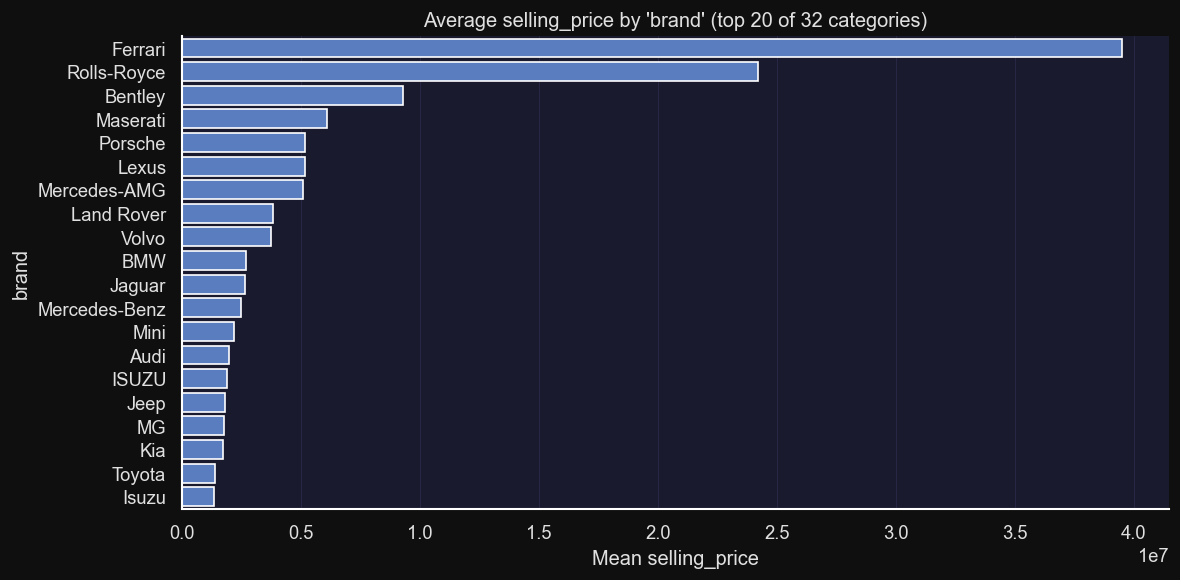

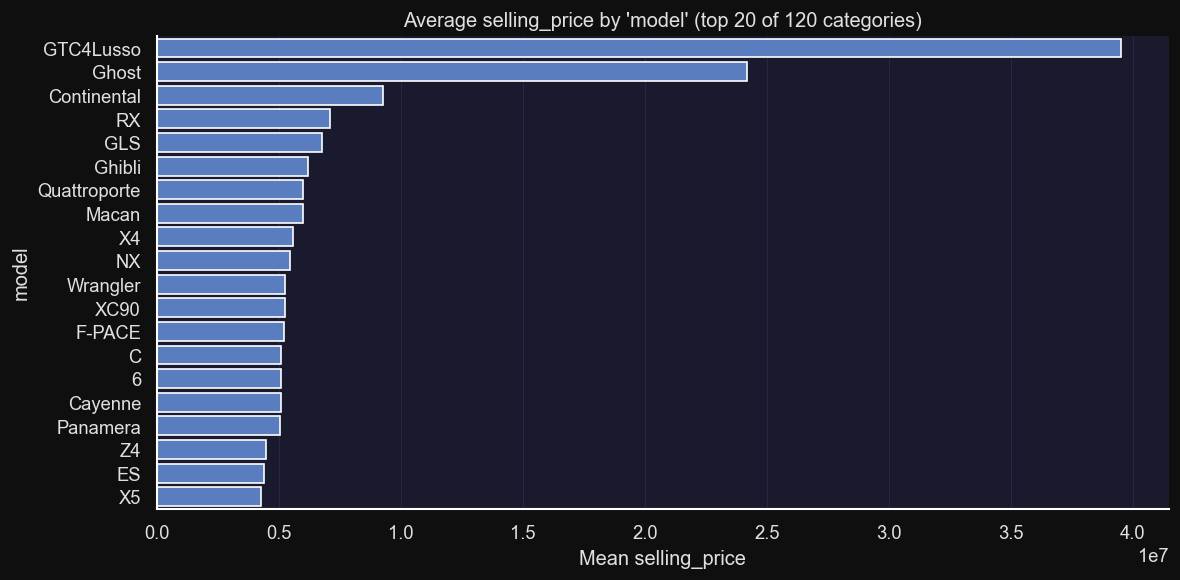

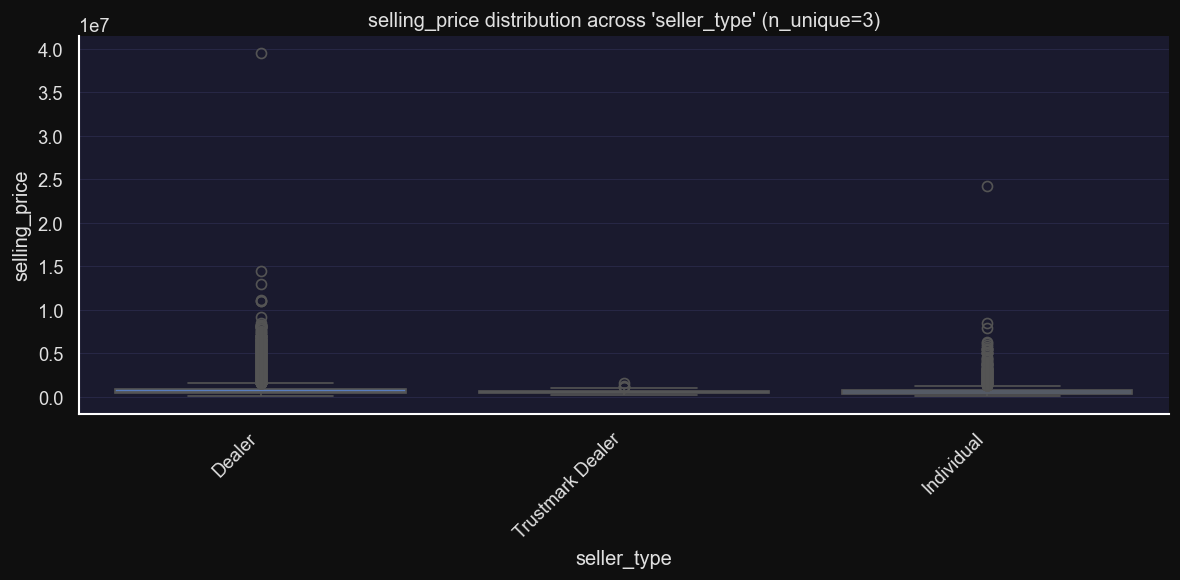

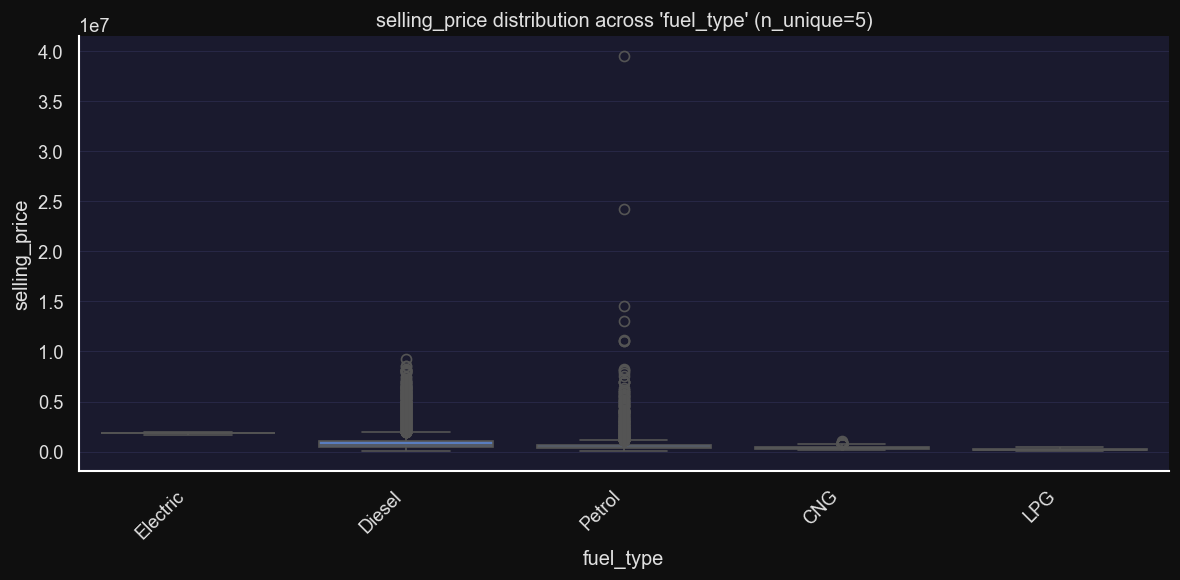

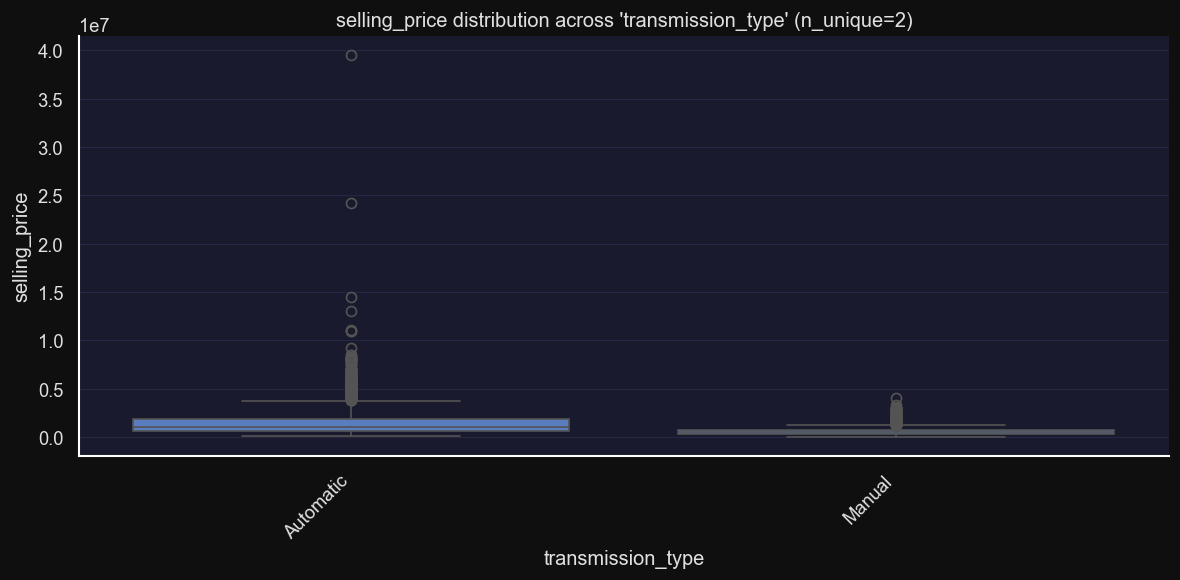

In [19]:
plot_all_categoricals(df, ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type'], 'selling_price')

In [20]:
outlier_report(df, df.select_dtypes(include=['int64', 'float64']).columns.tolist())

,column,n_values,iqr_lower_bound,iqr_upper_bound,iqr_outlier_count,iqr_outlier_pct,zscore_threshold,zscore_outlier_count,zscore_outlier_pct,min,max
0,vehicle_age,15411,-2.00,14.00,154,1.00,3.0,64,0.42,0.0,29.00
1,km_driven,15411,-30000.00,130000.00,466,3.02,3.0,78,0.51,100.0,3800000.00
2,mileage,15411,8.45,31.25,88,0.57,3.0,57,0.37,4.0,33.54
3,engine,15411,619.50,2159.50,2130,13.82,3.0,72,0.47,793.0,6592.00
4,max_power,15411,9.05,182.25,867,5.63,3.0,300,1.95,38.4,626.00
5,seats,15411,5.00,5.00,2501,16.23,3.0,375,2.43,0.0,9.00
6,selling_price,15411,-275000.00,1485000.00,1386,8.99,3.0,292,1.89,40000.0,39500000.00


In [21]:
df.head()

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [22]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size = 0.2
)

In [24]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

In [25]:
target_enc_cols = ['brand', 'model']               
passthrough_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
binary_col = ['transmission_type']                 
onehot_cols = ['seller_type', 'fuel_type']         

In [26]:
preprocessor = ColumnTransformer(
    transformers = [
        ('binary_encoding', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), binary_col),
        ('onehot_encoding', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
        ('target_encoding', TargetEncoder(target_type='continuous', cv=7, smooth='auto'), target_enc_cols),
        ('passthrough', 'passthrough', passthrough_cols)
    ],
    remainder = 'drop' 
)

In [27]:
preprocessor.fit(x_train, y_train_log)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary_encoding', ...), ('onehot_encoding', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transforme

In [28]:
X_train = preprocessor.transform(x_train)
X_test = preprocessor.transform(x_test)

<Axes: xlabel='selling_price', ylabel='Density'>

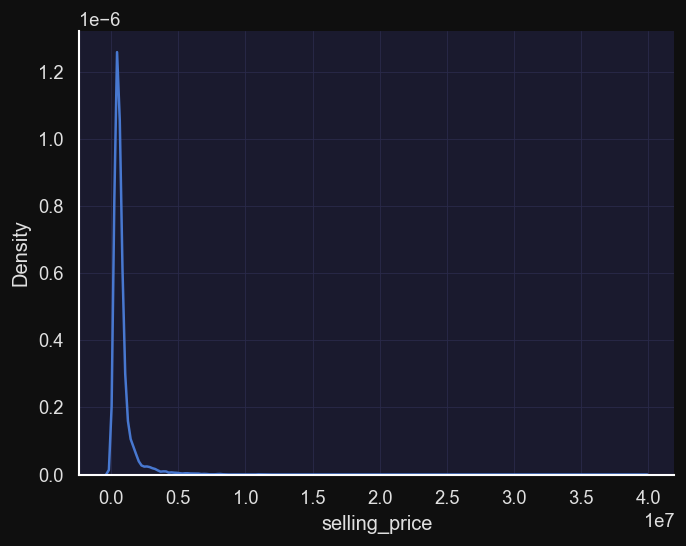

In [33]:
sns.kdeplot(y_train)

<Axes: xlabel='selling_price', ylabel='Density'>

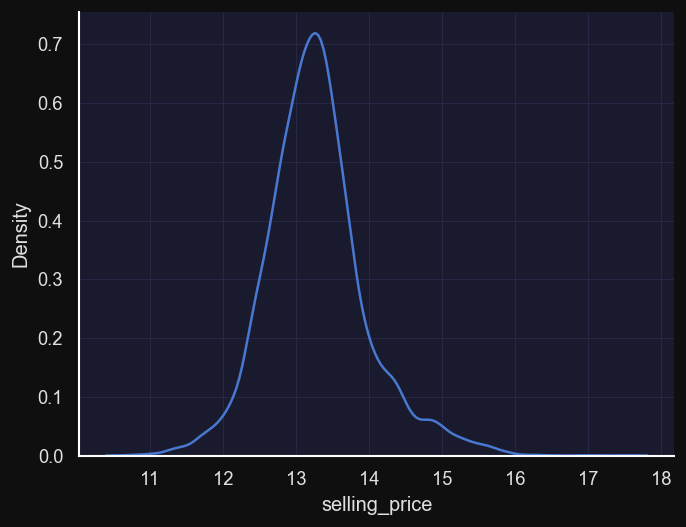

In [34]:
sns.kdeplot(y_train_log)

In [29]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [35]:
CV_FOLDS     = 5
N_TRIALS     = 150                           # ↑ from 50
RANDOM_STATE = 42
SCORING      = "neg_root_mean_squared_error"
EARLY_STOP   = 50                            # XGBoost early stopping rounds
 
 
# ── Objectives ────────────────────────────────────────────────────────────────
 
def decision_tree_objective(trial):
    params = {
        "max_depth"         : trial.suggest_int("max_depth", 2, 30),
        "min_samples_split" : trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf"  : trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features"      : trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "criterion"         : trial.suggest_categorical("criterion", ["squared_error", "friedman_mse", "absolute_error"]),
        "splitter"          : trial.suggest_categorical("splitter", ["best", "random"]),
        "random_state"      : RANDOM_STATE,
    }
    model = DecisionTreeRegressor(**params)
    scores = cross_val_score(model, X_train, y_train_log, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
    return scores.mean()
 
 
def random_forest_objective(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 50, 500),
        "max_depth"         : trial.suggest_int("max_depth", 2, 30),
        "min_samples_split" : trial.suggest_int("min_samples_split", 2, 30),
        "min_samples_leaf"  : trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features"      : trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 1.0]),
        "bootstrap"         : trial.suggest_categorical("bootstrap", [True, False]),
        "criterion"         : trial.suggest_categorical("criterion", ["squared_error", "absolute_error", "friedman_mse"]),
        "random_state"      : RANDOM_STATE,
        "n_jobs"            : -1,
    }
    model = RandomForestRegressor(**params)
    scores = cross_val_score(model, X_train, y_train_log, cv=CV_FOLDS, scoring=SCORING, n_jobs=-1)
    return scores.mean()
 
 
def xgboost_objective(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 100, 1000),  # wider range for early stopping
        "max_depth"         : trial.suggest_int("max_depth", 2, 12),
        "learning_rate"     : trial.suggest_float("learning_rate", 1e-4, 0.5, log=True),
        "subsample"         : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "colsample_bylevel" : trial.suggest_float("colsample_bylevel", 0.3, 1.0),
        "min_child_weight"  : trial.suggest_int("min_child_weight", 1, 20),
        "gamma"             : trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha"         : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"        : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "grow_policy"       : trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "objective"         : "reg:squarederror",
        "random_state"      : RANDOM_STATE,
        "n_jobs"            : -1,
        "early_stopping_rounds": EARLY_STOP,
        "eval_metric"       : "rmse",
    }
    model = xgb.XGBRegressor(**params)
    # Use fit with eval_set for early stopping inside objective
    model.fit(
        X_train, y_train_log,
        eval_set=[(X_test, y_test_log)],
        verbose=False,
    )
    y_pred_log = model.predict(X_test)
    rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
    return -rmse_log   # maximize negative RMSE

In [36]:
# ── Model registry ────────────────────────────────────────────────────────────
 
MODELS = {
    "DecisionTree": (decision_tree_objective, DecisionTreeRegressor),
    "RandomForest": (random_forest_objective, RandomForestRegressor),
    "XGBoost"     : (xgboost_objective,       xgb.XGBRegressor),
}
 
XGB_EXTRA = {
    "objective"             : "reg:squarederror",
    "eval_metric"           : "rmse",
    "early_stopping_rounds" : EARLY_STOP,
    "n_jobs"                : -1,
}
 
 
# ── Tune ──────────────────────────────────────────────────────────────────────
 
results = {}
 
print("=" * 60)
print("Tree Regression Tuning — Optuna")
print(f"Metric: {SCORING} | Trials: {N_TRIALS} | CV: {CV_FOLDS}-fold")
print("=" * 60)
 
for name, (objective, ModelClass) in MODELS.items():
    print(f"\n[{name}] Tuning {N_TRIALS} trials...")
 
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
 
    best_params = study.best_params.copy()
    best_params["random_state"] = RANDOM_STATE
 
    if name == "XGBoost":
        best_params.update(XGB_EXTRA)
        best_model = ModelClass(**best_params)
        best_model.fit(
            X_train, y_train_log,
            eval_set=[(X_test, y_test_log)],
            verbose=False,
        )
    else:
        best_model = ModelClass(**best_params)
        best_model.fit(X_train, y_train_log)
 
    # Inverse transform → original price scale
    y_pred      = np.expm1(best_model.predict(X_test))
    y_test_orig = np.expm1(y_test_log)
 
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    mae  = mean_absolute_error(y_test_orig, y_pred)
    r2   = r2_score(y_test_orig, y_pred)
 
    results[name] = {
        "study"      : study,
        "best_params": best_params,
        "model"      : best_model,
        "cv_score"   : study.best_value,
        "test_rmse"  : rmse,
        "test_mae"   : mae,
        "test_r2"    : r2,
        "y_pred"     : y_pred,
    }
 
    print(f"  CV Score (neg-RMSE log scale)  : {study.best_value:.4f}")
    print(f"  Test RMSE : {rmse:.4f}")
    print(f"  Test MAE  : {mae:.4f}")
    print(f"  Test R²   : {r2:.4f}")
    print(f"  Best Params: {study.best_params}")
 
 
# ── Summary ───────────────────────────────────────────────────────────────────
 
print("\n" + "=" * 60)
print(f"{'Model':<15} {'CV Score':>12} {'Test RMSE':>12} {'Test MAE':>10} {'Test R²':>10}")
print("-" * 60)
for name, res in results.items():
    print(f"{name:<15} {res['cv_score']:>12.4f} {res['test_rmse']:>12.4f} {res['test_mae']:>10.4f} {res['test_r2']:>10.4f}")
 
winner = min(results, key=lambda n: results[n]["test_rmse"])
print("=" * 60)
print(f"Winner (lowest test RMSE): {winner}  →  RMSE={results[winner]['test_rmse']:.4f}")
print("=" * 60)

Tree Regression Tuning — Optuna
Metric: neg_root_mean_squared_error | Trials: 150 | CV: 5-fold

[DecisionTree] Tuning 150 trials...


Best trial: 15. Best value: -0.185714: 100%|██████████| 150/150 [00:41<00:00,  3.57it/s]


  CV Score (neg-RMSE log scale)  : -0.1857
  Test RMSE : 315592.1005
  Test MAE  : 112550.8574
  Test R²   : 0.8583
  Best Params: {'max_depth': 25, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': None, 'criterion': 'friedman_mse', 'splitter': 'random'}

[RandomForest] Tuning 150 trials...


Best trial: 87. Best value: -0.165978: 100%|██████████| 150/150 [21:33<00:00,  8.62s/it]


  CV Score (neg-RMSE log scale)  : -0.1660
  Test RMSE : 276523.7076
  Test MAE  : 93596.5773
  Test R²   : 0.8912
  Best Params: {'n_estimators': 345, 'max_depth': 14, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 0.5, 'bootstrap': False, 'criterion': 'friedman_mse'}

[XGBoost] Tuning 150 trials...


Best trial: 94. Best value: -0.162933: 100%|██████████| 150/150 [02:36<00:00,  1.04s/it]


  CV Score (neg-RMSE log scale)  : -0.1629
  Test RMSE : 238869.6193
  Test MAE  : 90410.9172
  Test R²   : 0.9188
  Best Params: {'n_estimators': 379, 'max_depth': 7, 'learning_rate': 0.08346441198913658, 'subsample': 0.7435506054825762, 'colsample_bytree': 0.948751906518353, 'colsample_bylevel': 0.9501603886095981, 'min_child_weight': 19, 'gamma': 0.01841070780960037, 'reg_alpha': 2.157966568700442e-08, 'reg_lambda': 0.011498450677856022, 'grow_policy': 'lossguide'}

Model               CV Score    Test RMSE   Test MAE    Test R²
------------------------------------------------------------
DecisionTree         -0.1857  315592.1005 112550.8574     0.8583
RandomForest         -0.1660  276523.7076 93596.5773     0.8912
XGBoost              -0.1629  238869.6193 90410.9172     0.9188
Winner (lowest test RMSE): XGBoost  →  RMSE=238869.6193



Plotting residuals for winner: XGBoost


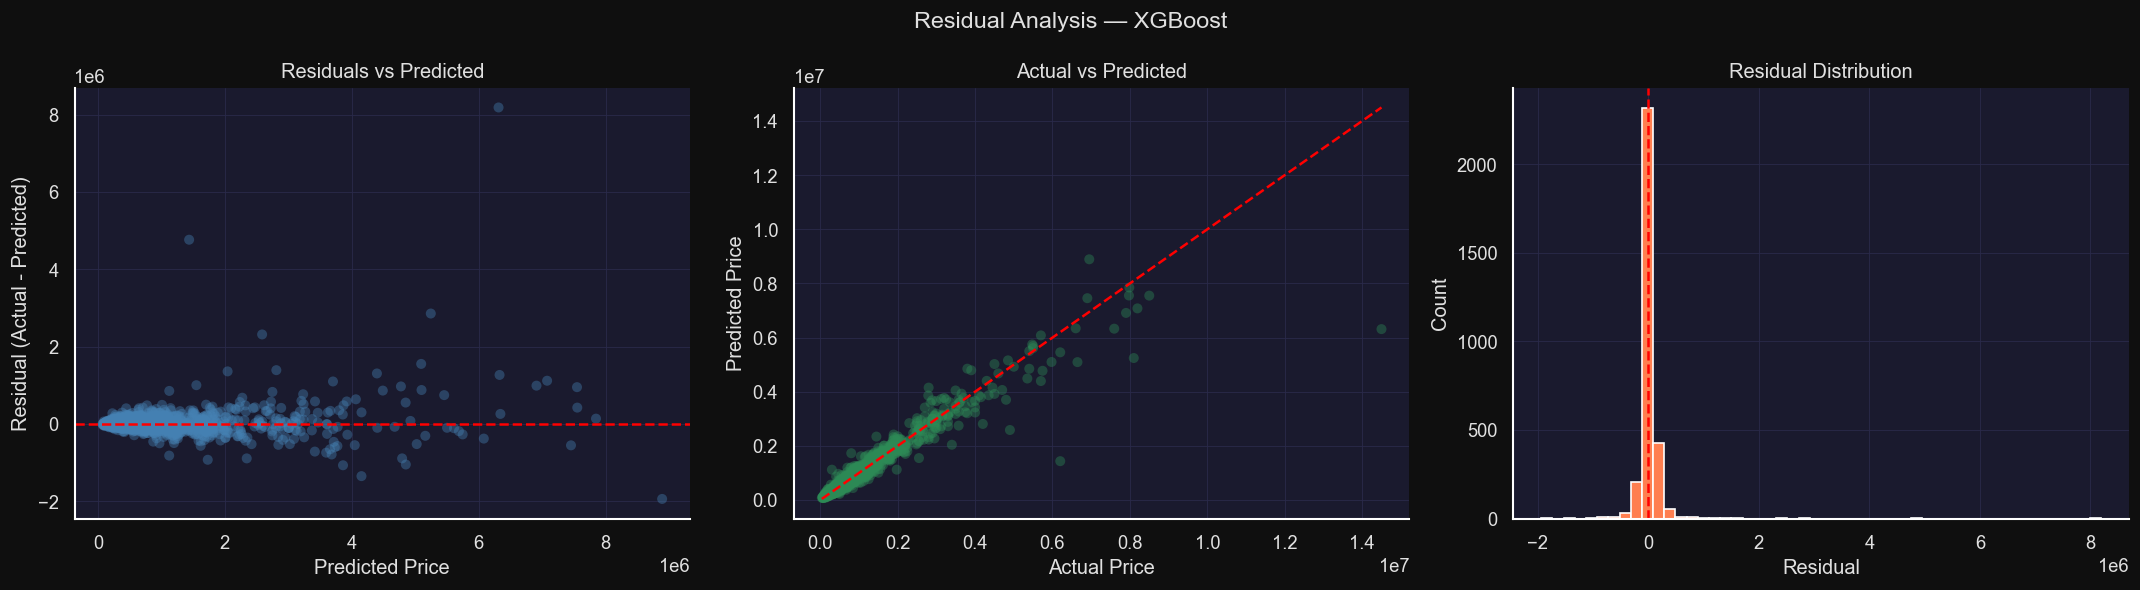

In [39]:

 
# ── Residuals Plot (winner only) ──────────────────────────────────────────────
 
print(f"\nPlotting residuals for winner: {winner}")
 
y_test_orig  = np.expm1(y_test_log)
y_pred_best  = results[winner]["y_pred"]
residuals    = y_test_orig - y_pred_best
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Residual Analysis — {winner}", fontsize=14)
 
# Plot 1: Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.4, color="steelblue", edgecolors="none")
axes[0].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")
 
# Plot 2: Actual vs Predicted
axes[1].scatter(y_test_orig, y_pred_best, alpha=0.4, color="seagreen", edgecolors="none")
min_val = min(y_test_orig.min(), y_pred_best.min())
max_val = max(y_test_orig.max(), y_pred_best.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Actual vs Predicted")
 
# Plot 3: Residual distribution
axes[2].hist(residuals, bins=50, color="coral", edgecolor="white")
axes[2].axvline(0, color="red", linewidth=1.5, linestyle="--")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Count")
axes[2].set_title("Residual Distribution")
 
plt.tight_layout()
plt.show()

In [41]:
xgb_model     = results["XGBoost"]["model"]
xgb_params    = results["XGBoost"]["best_params"]
xgb_metrics   = {
    "cv_score" : results["XGBoost"]["cv_score"],
    "test_rmse": results["XGBoost"]["test_rmse"],
    "test_mae" : results["XGBoost"]["test_mae"],
    "test_r2"  : results["XGBoost"]["test_r2"],
}

In [44]:
SAVE_DIR = "..\\app\\models"

joblib.dump(xgb_model, f"{SAVE_DIR}\\xgb_model.pkl")
print(f"✓ Model saved       → {SAVE_DIR}\\xgb_model.pkl")
 
joblib.dump(preprocessor, f"{SAVE_DIR}\\preprocessor.pkl")
print(f"✓ Pipeline saved       → {SAVE_DIR}\\preprocessor_model.pkl")

✓ Model saved       → ..\app\models\xgb_model.pkl
✓ Pipeline saved       → ..\app\models\preprocessor_model.pkl


In [45]:
with open(f"{SAVE_DIR}/xgb_best_params.json", "w") as f:
    json.dump(xgb_params, f, indent=2)
print(f"✓ Best params saved → {SAVE_DIR}/xgb_best_params.json")

with open(f"{SAVE_DIR}/xgb_metrics.json", "w") as f:
    json.dump(xgb_metrics, f, indent=2)
print(f"✓ Metrics saved     → {SAVE_DIR}/xgb_metrics.json")

✓ Best params saved → ..\app\models/xgb_best_params.json
✓ Metrics saved     → ..\app\models/xgb_metrics.json
